SECTION 1 Setup

In [1]:
!pip install scikit-surprise -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 30.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

from tqdm import tqdm

from sklearn.metrics import mean_squared_error

from surprise import Dataset
from surprise import Reader
from surprise import SVD

SECTION 2 Load Data

(Load per-user temporal split)

In [3]:
train_df = pd.read_csv(
    "train_per_user_temporal.csv"
)

test_df = pd.read_csv(
    "test_per_user_temporal.csv"
)

SECTION 3 User Activity Analysis

(Study rating counts per user)

How many users are cold-start users and how active are Netflix users?

In [4]:
user_activity = (
    train_df
    .groupby("user_id")
    .size()
)

In [5]:
user_activity.describe()

,0
count,289225.000000
mean,4.206206
std,5.359263
min,1.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,302.000000


In [6]:
# Users with Few Ratings
for threshold in [5,10,20,50]:

    pct = (
        (user_activity < threshold).sum()
        /
        len(user_activity)
    ) * 100

    print(
        f"Users with < {threshold} ratings:",
        round(pct,2),
        "%"
    )

Users with < 5 ratings: 72.73 %
Users with < 10 ratings: 88.97 %
Users with < 20 ratings: 97.71 %
Users with < 50 ratings: 99.94 %


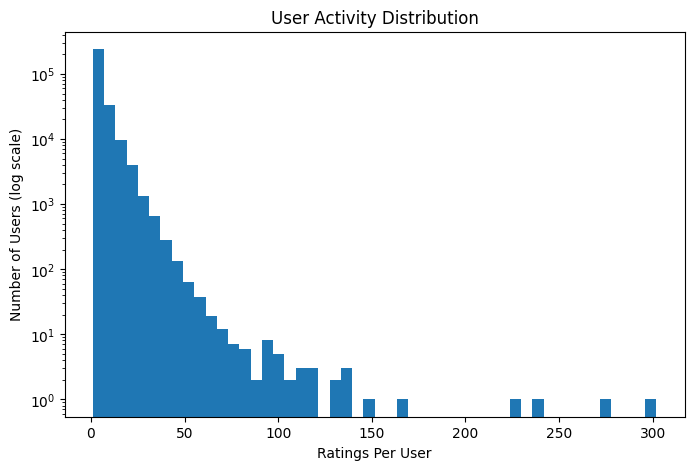

In [7]:
# Activity Distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    user_activity,
    bins=50,
    log=True
)

plt.title(
    "User Activity Distribution"
)

plt.xlabel(
    "Ratings Per User"
)

plt.ylabel(
    "Number of Users (log scale)"
)

plt.show()

Most users contribute only a small number of ratings, while a few highly active users contribute many ratings.

SECTION 4 Train Best SVD

(Use best model from Notebook 08)

In [8]:
reader = Reader(
    rating_scale=(1,5)
)

data = Dataset.load_from_df(
    train_df[
        [
            "user_id",
            "movie_id",
            "rating"
        ]
    ],
    reader
)

trainset = data.build_full_trainset()

In [9]:
svd_model = SVD(
    n_factors=100,
    n_epochs=50,
    lr_all=0.003,
    reg_all=0.05,
    random_state=42
)

In [10]:
svd_model.fit(
    trainset
)

SECTION 5 Generate Predictions

(Predict ratings on test set)

In [11]:
predictions = []

for row in tqdm(
    test_df.itertuples(),
    total=len(test_df)
):

    pred = svd_model.predict(
        row.user_id,
        row.movie_id
    )

    predictions.append(
        pred.est
    )

100%|██████████| 493065/493065 [00:03<00:00, 151141.37it/s]


In [12]:
eval_df = test_df.copy()

eval_df[
    "predicted_rating"
] = predictions

SECTION 6 User Segments

(Create activity groups)

Does recommendation quality improve for more active users?

In [13]:
activity_df = user_activity.reset_index()

activity_df.columns = [
    "user_id",
    "rating_count"
]

In [14]:
eval_df = eval_df.merge(
    activity_df,
    on="user_id",
    how="left"
)

In [15]:
eval_df["segment"] = pd.cut(
    eval_df["rating_count"],
    bins=[0,5,20,100,1000],
    labels=[
        "Cold",
        "Light",
        "Medium",
        "Heavy"
    ]
)

SECTION 7 RMSE by Segment

(Evaluate user groups separately)

In [16]:
def rmse(
    actual,
    predicted
):

    return np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

In [17]:
segment_results = []

In [18]:
for segment in [
    "Cold",
    "Light",
    "Medium",
    "Heavy"
]:

    subset = eval_df[
        eval_df["segment"]
        == segment
    ]

    if len(subset) == 0:
        continue

    score = rmse(
        subset["rating"],
        subset["predicted_rating"]
    )

    segment_results.append([
        segment,
        len(subset),
        score
    ])

In [19]:
segment_results = pd.DataFrame(
    segment_results,
    columns=[
        "Segment",
        "Ratings",
        "RMSE"
    ]
)

segment_results

,Segment,Ratings,RMSE
0,Cold,174150,1.012101
1,Light,183620,0.937105
2,Medium,39482,0.933047
3,Heavy,816,1.118339


SECTION 8 Segment Comparison

(Compare performance across activity levels)

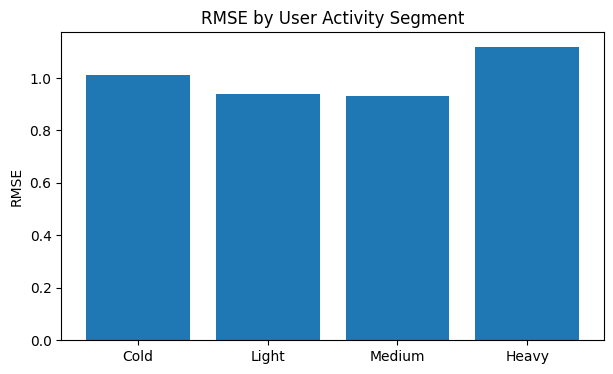

In [20]:
plt.figure(figsize=(7,4))

plt.bar(
    segment_results["Segment"],
    segment_results["RMSE"]
)

plt.title(
    "RMSE by User Activity Segment"
)

plt.ylabel(
    "RMSE"
)

plt.show()

Prediction accuracy generally improves as user activity increases because more interaction history is available for learning preferences.